中医药NER

In [7]:
import json
import pandas as pd
import torch
from datasets import Dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForSeq2Seq,AutoTokenizer,TrainerCallback
import numpy as np
import evaluate
import re
from collections import defaultdict

文件格式转换

In [8]:
types = set()
def _build_sample(chars, labels):
    sentence = ''.join(chars)
    entities = []
    idx = 0
    current = None
    for ch, tag in zip(chars, labels):
        if tag.startswith('B-'):
            if current:
                entities.append(current)
            ent_type = tag.split('-', 1)[1]
            current = {"entity_text": ch, "entity_label": ent_type} #, "start": idx, "end": idx+1}
            types.add(ent_type)
        elif tag.startswith('I-') and current and current["entity_label"] == tag.split('-', 1)[1]:
            current["entity_text"] += ch
            # current["end"] = idx + 1
        else:
            if current:
                entities.append(current)
                current = None
        idx += 1
    if current:
        entities.append(current)
    
    message = {
        "instruction": """你是一个中医文本实体识别领域的专家，你需要从给定的句子中提取 中医治则; 中医治疗; 中医证候; 中医诊断; 中药; 临床表现; 其他治疗; 方剂; 西医治疗; 西医诊断. 以 json 格式输出, 如 {"entity_text": "首乌", "entity_label": "中药"} 注意: 1. 输出的每一行都必须是正确的 json 字符串. 2. 找不到任何实体时, 输出"没有找到任何实体". """,
        "input": f"文本:{sentence}",
        "output": entities,
    }

    return message

In [9]:
def dataset_jsonl_transfer(origin_path, new_path):
    """
    将原始数据集转换为大模型微调所需数据格式的新数据集
    """
    messages = []

    # 读取旧的文件
    # B为开始，I继续，O为不包含实体
    with open(origin_path, "r",encoding='utf-8') as file:
        chars, labels = [], []
        for line in file:
            line = line.strip()
            if not line:
                if chars:
                    messages.append(_build_sample(chars, labels))
                    chars, labels = [], []
                continue
            try:
                char, tag = line.split()
                chars.append(char)
                labels.append(tag)
            except :
                tag = line
                char = ' '
                chars.append(char)
                labels.append(tag)

        if chars:
            messages.append(_build_sample(chars, labels))


    # 保存重构后的JSONL文件
    with open(new_path, "w", encoding="utf-8") as file:
        for message in messages:
            file.write(json.dumps(message, ensure_ascii=False) + "\n")

In [10]:
train_dataset_path = "datasets/medical.train"
train_jsonl_new_path = "datasets/medical_train.jsonl"

dataset_jsonl_transfer(train_dataset_path,train_jsonl_new_path)

In [11]:
test_dataset_path = "datasets/medical.test"
test_jsonl_new_path = "datasets/medical_test.jsonl"

dataset_jsonl_transfer(test_dataset_path,test_jsonl_new_path)
dev_dataset_path = "datasets/medical.dev"
dev_jsonl_new_path = "datasets/medical_dev.jsonl"

dataset_jsonl_transfer(dev_dataset_path,dev_jsonl_new_path)

In [12]:
types

{'中医治则', '中医治疗', '中医证候', '中医诊断', '中药', '临床表现', '其他治疗', '方剂', '西医治疗', '西医诊断'}

模型加载

In [13]:
model_id = "qwen/Qwen2.5-7B-Instruct"
model_dir = "F:\\learnllm\\homework\\peft\\qwen\\Qwen2___5-7B-Instruct"

# Transformers加载模型权重
tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=False, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_dir, device_map="auto", torch_dtype=torch.bfloat16)
model.enable_input_require_grads()  # 开启梯度检查点时，要执行该方法

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

数据处理

In [14]:
#从字符串中提取字典
def extract_all_and_swap(text: str) -> dict[str, list[str]]:
    """
    从输入字符串中提取所有符合 {"text":"...","type":"..."} 的字典，
    并把它们转换为 {type: [text1, text2, ...]} 的映射。
    返回一个 dict，value 用列表收集所有同类型的 text。
    """
    pattern = re.compile(
        r"\{\s*'entity_label'\s*:\s*'(?P<label>[^']+)'\s*,\s*"
        r"'entity_text'\s*:\s*'(?P<ent>[^']+)'\s*\}"
    )
    result = defaultdict(list)
    for m in pattern.finditer(text):
        t = m.group("label")
        txt = m.group("ent")
        result[t].append(txt)
    return dict(result)

In [15]:
#计算两个list之间的f1、precision、recall
def dict_p_r_f1(pred_list: list[str], goal_list: list[str]) -> dict[str, float]:
    """
    计算两个字典的 Precision、Recall 和 F1。
    以 (key, value) 对作为“样本”，只要完全匹配才算命中。

    Args:
        pred_list: 预测的 list，键和值均为 str。
        goal_list: 真实的 list，键和值均为 str。

    Returns:
        {
            'precision': float,
            'recall': float,
            'f1': float
        }
    """
    # 将字典项转换为 (key, value) 的集合
    pred_items = set(pred_list)
    goal_items = set(goal_list)

    # 计算 True Positives（TP）：预测-真实交集
    tp = len(pred_items & goal_items)
    # 预测总数、真实总数
    pred_count = len(pred_items)
    goal_count = len(goal_items)

    precision = tp / pred_count if pred_count > 0 else 0.0
    recall    = tp / goal_count if goal_count > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return {'precision': precision, 'recall': recall, 'f1': f1}

In [16]:
def process_func(example):
    """
    将数据集进行预处理
    """

    MAX_LENGTH = 384
    input_ids, attention_mask, labels = [], [], []
    system_prompt = """你是一个中医文本实体识别领域的专家，你需要从给定的句子中提取 中医治则; 中医治疗; 中医证候; 中医诊断; 中药; 临床表现; 其他治疗; 方剂; 西医治疗; 西医诊断. 以 json 格式输出, 如 {"entity_text": "首乌", "entity_label": "中药"} 注意: 1. 输出的每一行都必须是正确的 json 字符串. 2. 找不到任何实体时, 输出"没有找到任何实体". """,
        
    instruction = tokenizer(
        f"<|im_start|>system\n{system_prompt}<|im_end|>\n<|im_start|>user\n{example['input']}<|im_end|>\n<|im_start|>assistant\n",
        add_special_tokens=False,
    )
    response = tokenizer(f"{example['output']}", add_special_tokens=False)
    input_ids = instruction["input_ids"] + response["input_ids"] + [tokenizer.pad_token_id]
    attention_mask = (
        instruction["attention_mask"] + response["attention_mask"] + [1]
    )
    labels = [-100] * len(instruction["input_ids"]) + response["input_ids"] + [tokenizer.pad_token_id]
    if len(input_ids) > MAX_LENGTH:  # 做一个截断
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


In [17]:

# metric = evaluate.load("seqeval")

f1_dict = {'中医治则':[], '中医治疗':[], '中医证候':[], '中医诊断':[], '中药':[], '临床表现':[], '其他治疗':[], '方剂':[], '西医治疗':[], '西医诊断':[]}
f1_total_dict = {'中医治则':[], '中医治疗':[], '中医证候':[], '中医诊断':[], '中药':[], '临床表现':[], '其他治疗':[], '方剂':[], '西医治疗':[], '西医诊断':[]}

#计算F1

#计算F1
def compute_metrics(p,compute_result):

    predictions, labels = p
    predictions = predictions.type(dtype=torch.float32).cpu().numpy()
    labels = labels.type(dtype=torch.float32).cpu().numpy()
    predictions = np.argmax(predictions, axis=2)
    for pred_seq, label_seq in zip(predictions, labels):
        temp_true = []
        temp_pred = []
        for pred_label, true_label in zip(pred_seq, label_seq):
            if true_label != -100:
                temp_true.append(true_label)
                temp_pred.append(pred_label)
        temp_true = tokenizer.decode(
            temp_true,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True
        )
        true_dic = extract_all_and_swap(temp_true)
        temp_pred = tokenizer.decode(
            temp_pred,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True
        )
        pred_dic = extract_all_and_swap(temp_pred)
        for key in f1_dict.keys():
            if key in true_dic.keys() and key in pred_dic.keys():
                score = dict_p_r_f1(pred_dic[key],true_dic[key])
                f1_dict[key].append(score)

    if compute_result:
        print(f1_dict)
        total_f1 = 0
        total_precision = 0
        total_recall = 0
        count_f1 = 0
        for key, values in f1_dict.items():
            for value in values:
                total_f1 += value['f1']
                total_precision += value['precision']
                total_recall += value['recall']
                count_f1 += 1
            key_f1 = sum([v['f1'] for v in values]) / len(values) if len(values) > 0 else 0
            f1_total_dict[key].append(key_f1)
            values.clear()

        return {
            'precision': total_precision/count_f1,
            'recall': total_recall/count_f1,
            'f1': total_f1/count_f1
        }

    return {
            'precision': 0,
            'recall': 0,
            'f1': 0
        }



In [18]:
class F1PrintCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            f1 = metrics.get("eval_f1", None)
            precision = metrics.get("eval_precision", None)
            recall = metrics.get("eval_recall", None)

            if f1 is not None:
                print(f"\n⭐ 评估结果 - Epoch {state.epoch}/{args.num_train_epochs}")
                print(f"F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
                print("-" * 50)

In [19]:
train_jsonl_new_path = "datasets/medical_train.jsonl"

total_df = pd.read_json(train_jsonl_new_path, lines=True)
train_df = total_df[int(len(total_df) * 0.1):]
train_ds = Dataset.from_pandas(train_df)
train_dataset = train_ds.map(process_func, remove_columns=train_ds.column_names)


dev_jsonl_new_path = "datasets/medical_dev.jsonl"

total_df = pd.read_json(dev_jsonl_new_path, lines=True)
train_df = total_df[int(len(total_df) * 0.1):]
train_ds = Dataset.from_pandas(train_df)
eval_dataset = train_ds.map(process_func, remove_columns=train_ds.column_names)

Map:   0%|          | 0/4734 [00:00<?, ? examples/s]

Map:   0%|          | 0/592 [00:00<?, ? examples/s]

In [ ]:

config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    inference_mode=False,  # 训练模式
    r=8,  # Lora 秩
    lora_alpha=32,  # Lora alaph，具体作用参见 Lora 原理
    lora_dropout=0.1,  # Dropout 比例
)

model = get_peft_model(model, config)

args = TrainingArguments(
    output_dir="./output/Qwen2.5-MedicalNER",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    eval_accumulation_steps=2,
    eval_strategy="steps",
    eval_steps=30,
    logging_steps=10,
    num_train_epochs=3,
    learning_rate=1e-4,
    save_on_each_node=True,
    gradient_checkpointing=True,
    save_strategy="best",
    load_best_model_at_end=True,
    batch_eval_metrics=True,
    metric_for_best_model="f1",  # 使用F1选择最佳模型
    greater_is_better=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    callbacks=[F1PrintCallback()],  # 添加自定义回调
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True),
)

bin d:\ProgramData\anaconda3\Lib\site-packages\bitsandbytes\libbitsandbytes_cuda118.dll


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [21]:
trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss,Precision,Recall,F1
30,0.101100,0.100867,0.830921,0.827307,0.827145
60,0.090500,0.090401,0.849537,0.846866,0.846092
90,0.076800,0.084909,0.862037,0.861554,0.859342
120,0.079400,0.078101,0.843837,0.844164,0.841613
150,0.064900,0.071955,0.878811,0.868930,0.871903
180,0.059700,0.067250,0.879307,0.871126,0.873784
210,0.066200,0.071975,0.875247,0.868810,0.869889
240,0.068100,0.066527,0.864547,0.858152,0.859891
270,0.062500,0.066548,0.874799,0.869285,0.870790
300,0.058300,0.066447,0.879917,0.873319,0.874756


{'中医治则': [{'precision': 1.0, 'recall': 0.5, 'f1': 0.6666666666666666}, {'precision': 0.5, 'recall': 0.3333333333333333, 'f1': 0.4}, {'precision': 1.0, 'recall': 0.5, 'f1': 0.6666666666666666}, {'precision': 1.0, 'recall': 0.6666666666666666, 'f1': 0.8}, {'precision': 1.0, 'recall': 0.5, 'f1': 0.6666666666666666}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 0.3333333333333333, 'recall': 0.25, 'f1': 0.28571428571428575}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 0.5, 'recall': 0.4, 'f1': 0.4444444444444445}], '中医治疗': [{'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 1.0, 'recall': 1

TrainOutput(global_step=888, training_loss=0.05235107051762375, metrics={'train_runtime': 6416.9506, 'train_samples_per_second': 2.213, 'train_steps_per_second': 0.138, 'total_flos': 1.5761828205178675e+17, 'train_loss': 0.05235107051762375, 'epoch': 3.0})

In [22]:
# 最终评估
results = trainer.evaluate()
print(f"最终评估结果: F1={results['eval_f1']:.4f}")

{'中医治则': [{'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 1.0, 'recall': 0.5, 'f1': 0.6666666666666666}, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}, {'precision': 1.0, 'recall': 0.5, 'f1': 0.6666666666666666}, {'precision': 1.0, 'recall': 0.5, 'f1': 0.6666666666666666}, {'precision': 1.0, 'recall': 0.6666666666666666, 'f1': 0.8}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 1.0, 'recall': 0.5, 'f1': 0.6666666666666666}, {'precision': 1.0, 'recall': 0.6666666666666666, 'f1': 0.8}, {'precision': 0.5, 'recall': 0.5, 'f1': 0.5}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 0.6666666666666666, 'recall': 0.5, 'f1': 0.5714285714285715}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 1.0, 'recall': 0.8, 'f1': 0.888888888888889}, {'precision': 1.0, 'recall': 0.3333333333333333, 'f1': 0.5}], '中医治疗': [{'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, {'p

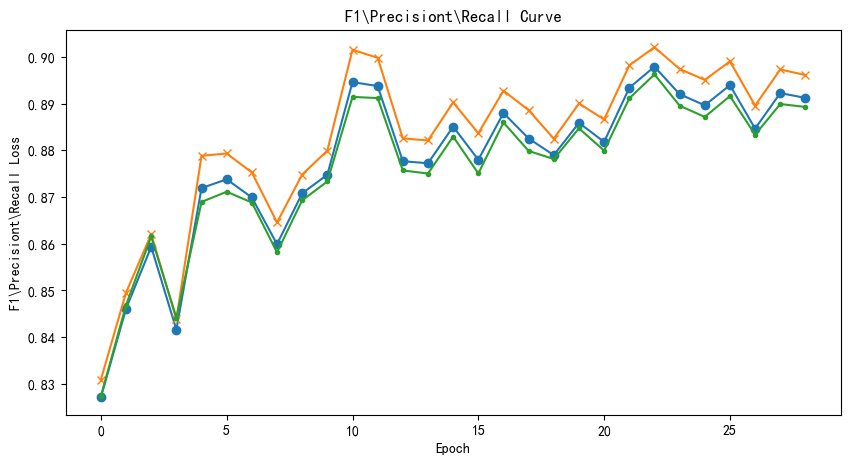

In [43]:
from matplotlib import pyplot as plt
plt.rcParams['font.family'] = 'SimHei'
#{'中医治则', '中医治疗', '中医证候', '中医诊断', '中药', '临床表现', '其他治疗', '方剂', '西医治疗', '西医诊断'}

f1_history = [0.827145,0.846092,0.859342,0.841613,0.871903,0.873784,0.869889,0.859891,0.87079,0.874756,0.894583,
              0.893733,0.877655,0.87721,0.885062,0.877957,0.88797,0.882512,0.878953,0.885866,0.881784,0.893358,
              0.897882,0.891994,0.889617,0.893929,0.884627,0.892233,0.891204,]
precision_history = [0.830921,0.849537,0.862037,0.843837,0.878811,0.879307,0.875247,0.864547,0.874799,0.879917,
                     0.901499,0.899783,0.882544,0.882093,0.890238,0.883643,0.892746,0.888574,0.88247,0.890008,
                     0.886589,0.898164,0.902047,0.897396,0.895066,0.899022,0.889558,0.897288,0.896088,]
recal_history = [0.827307,0.846866,0.861554,0.844164,0.86893,0.871126,0.86881,0.858152,0.869285,0.873319,0.891416,
                 0.89116,0.875675,0.87502,0.882927,0.875036,0.885938,0.879847,0.878115,0.884689,0.879918,0.891108,
                 0.896237,0.889541,0.887127,0.891594,0.88333,0.889889,0.889263,]

# 绘制 总的 f1 精确度 召回率 曲线
plt.figure(figsize=(10, 5))
plt.plot(f1_history, marker='o')
plt.plot(precision_history, marker='x')
plt.plot(recal_history, marker='.')
plt.xlabel("Epoch")
plt.ylabel("F1\Precisiont\Recall Loss")
plt.title("F1\Precisiont\Recall Curve")
plt.show()

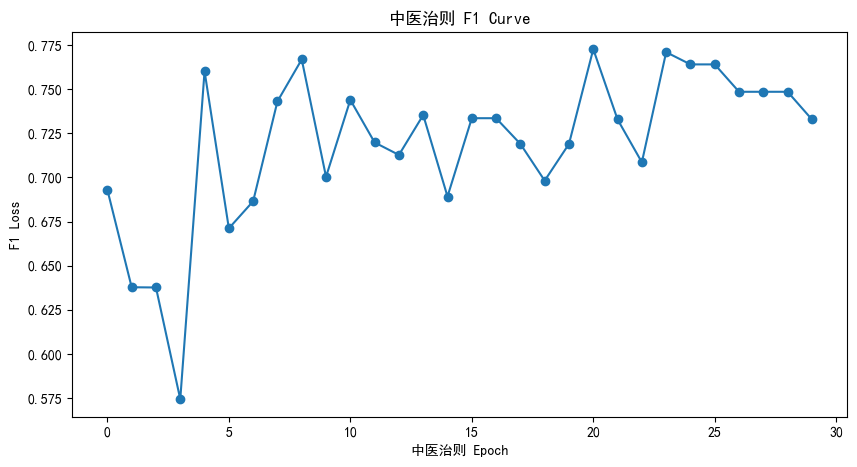

In [44]:
# 绘制 中医治则 f1 曲线
plt.figure(figsize=(10, 5))
plt.plot(f1_total_dict['中医治则'], marker='o')
plt.xlabel("中医治则 Epoch")
plt.ylabel("F1 Loss")
plt.title("中医治则 F1 Curve")
plt.show()

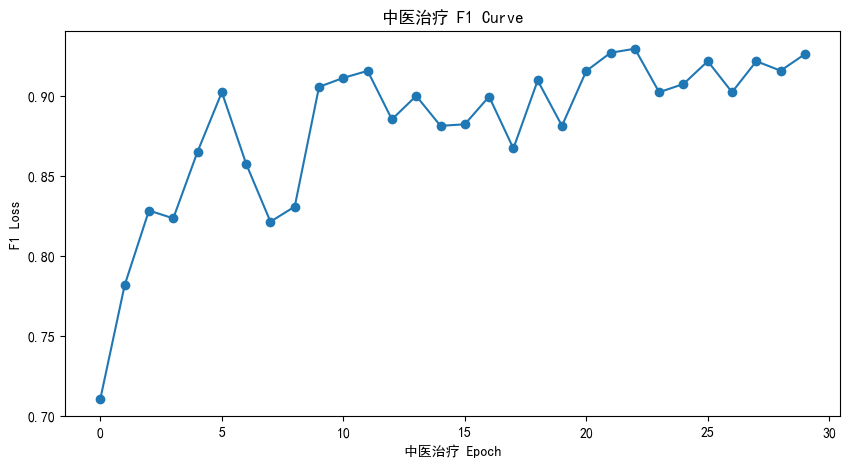

In [42]:
# 绘制 中医治疗 f1 曲线
plt.figure(figsize=(10, 5))
plt.plot(f1_total_dict['中医治疗'], marker='o')
plt.xlabel("中医治疗 Epoch")
plt.ylabel("F1 Loss")
plt.title("中医治疗 F1 Curve")
plt.show()

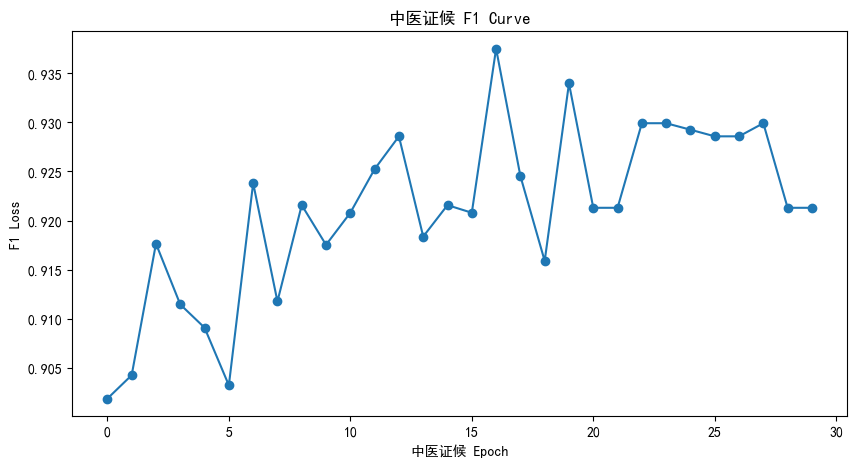

In [45]:
# 绘制 中医证候 f1 曲线
plt.figure(figsize=(10, 5))
plt.plot(f1_total_dict['中医证候'], marker='o')
plt.xlabel("中医证候 Epoch")
plt.ylabel("F1 Loss")
plt.title("中医证候 F1 Curve")
plt.show()

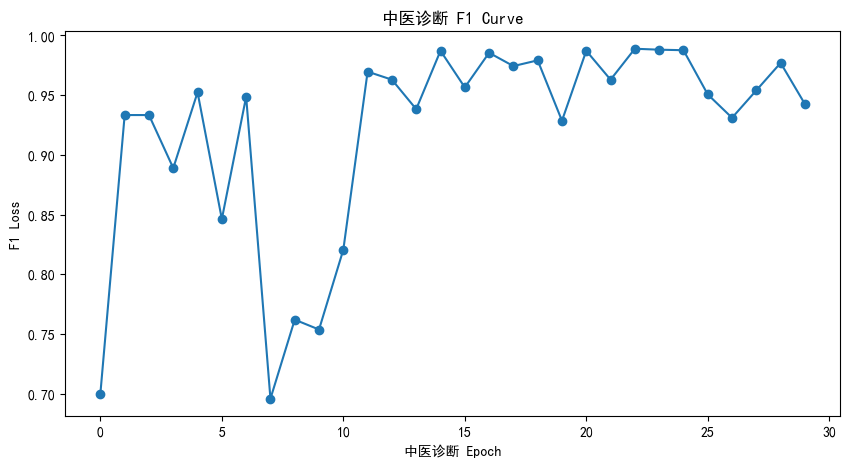

In [46]:
# 绘制 中医诊断 f1 曲线
plt.figure(figsize=(10, 5))
plt.plot(f1_total_dict['中医诊断'], marker='o')
plt.xlabel("中医诊断 Epoch")
plt.ylabel("F1 Loss")
plt.title("中医诊断 F1 Curve")
plt.show()

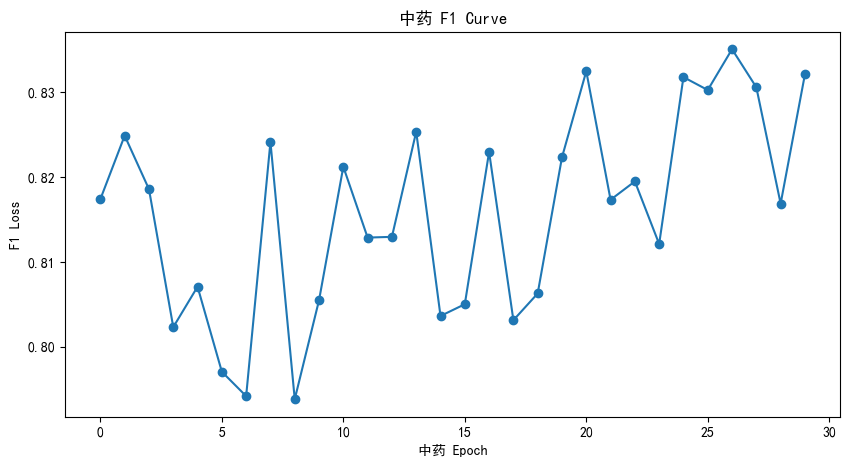

In [47]:
# 绘制 中药 f1 曲线
plt.figure(figsize=(10, 5))
plt.plot(f1_total_dict['中药'], marker='o')
plt.xlabel("中药 Epoch")
plt.ylabel("F1 Loss")
plt.title("中药 F1 Curve")
plt.show()

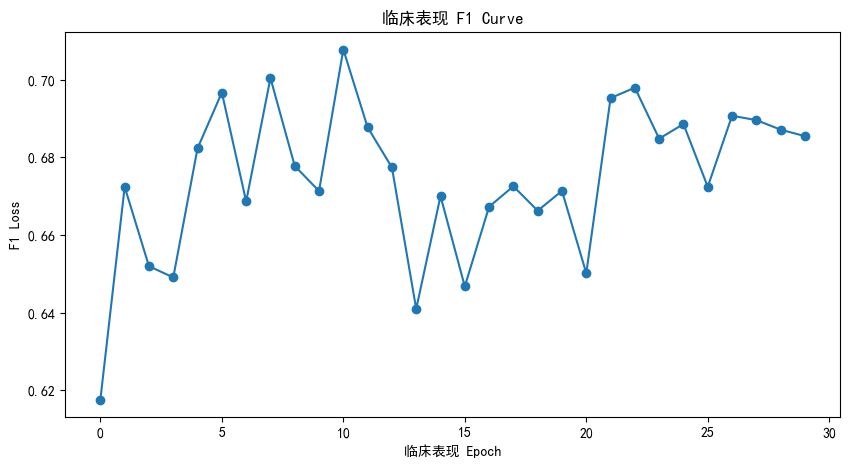

In [48]:
# 绘制 临床表现 f1 曲线
plt.figure(figsize=(10, 5))
plt.plot(f1_total_dict['临床表现'], marker='o')
plt.xlabel("临床表现 Epoch")
plt.ylabel("F1 Loss")
plt.title("临床表现 F1 Curve")
plt.show()

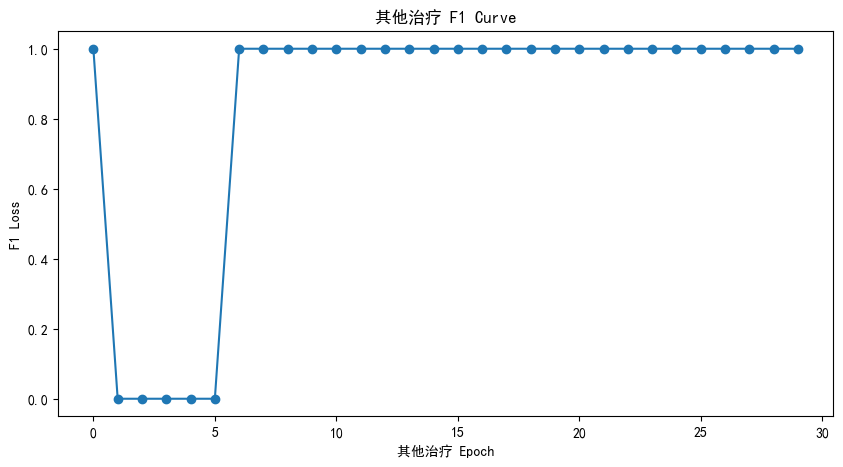

In [49]:
# 绘制 其他治疗 f1 曲线
plt.figure(figsize=(10, 5))
plt.plot(f1_total_dict['其他治疗'], marker='o')
plt.xlabel("其他治疗 Epoch")
plt.ylabel("F1 Loss")
plt.title("其他治疗 F1 Curve")
plt.show()

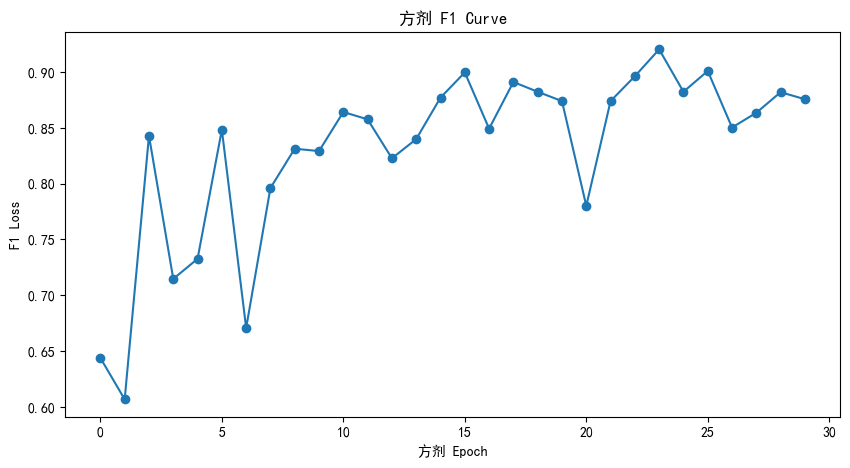

In [50]:
# 绘制 方剂 f1 曲线
plt.figure(figsize=(10, 5))
plt.plot(f1_total_dict['方剂'], marker='o')
plt.xlabel("方剂 Epoch")
plt.ylabel("F1 Loss")
plt.title("方剂 F1 Curve")
plt.show()

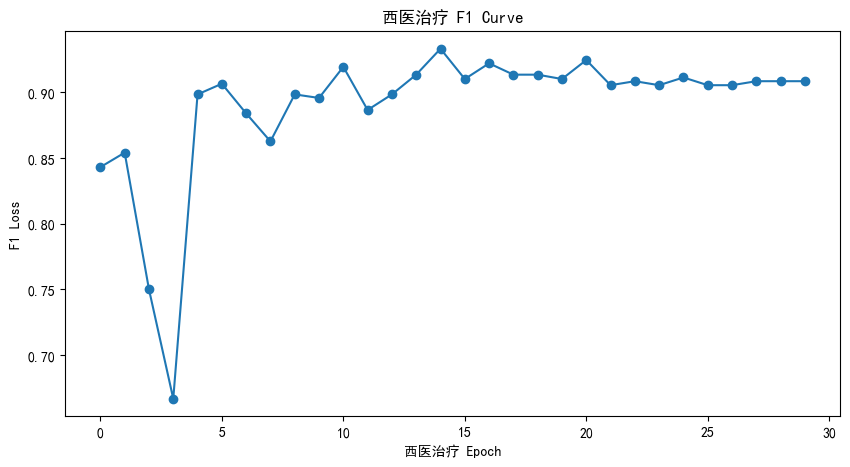

In [51]:
# 绘制 西医治疗 f1 曲线
plt.figure(figsize=(10, 5))
plt.plot(f1_total_dict['西医治疗'], marker='o')
plt.xlabel("西医治疗 Epoch")
plt.ylabel("F1 Loss")
plt.title("西医治疗 F1 Curve")
plt.show()

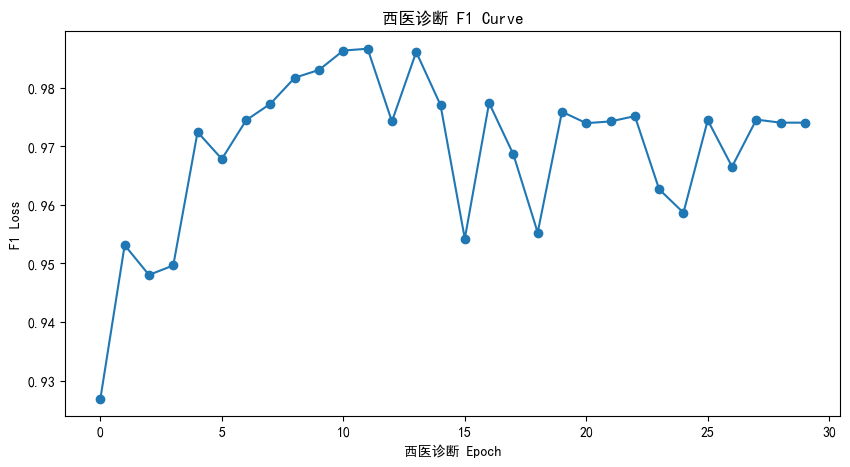

In [52]:
# 绘制 西医诊断 f1 曲线
plt.figure(figsize=(10, 5))
plt.plot(f1_total_dict['西医诊断'], marker='o')
plt.xlabel("西医诊断 Epoch")
plt.ylabel("F1 Loss")
plt.title("西医诊断 F1 Curve")
plt.show()

测试集

In [56]:
def test_loop_final(dataloader,tokenizer,model,device,save_path):
    labels = []
    predictions = []
    sources = []
    model.eval()
    for batch, data in enumerate(dataloader):
        data = data.to(device)
        with torch.no_grad():
            output = model.generate(data["input_ids"],
                attention_mask=data["attention_mask"],
                max_length=1280,
                num_beams=4,
                no_repeat_ngram_size=2,
            )
        if isinstance(output, tuple):
            output = output[0]
        
        decoded_sources = tokenizer.batch_decode(
            data["input_ids"].cpu().numpy(), 
            skip_special_tokens=True, 
            use_source_tokenizer=True
        )
        
        sources += [source.strip() for source in decoded_sources]

        decoded_preds = tokenizer.batch_decode(output, skip_special_tokens=True)
        predictions += [' '.join(pred.strip()) for pred in decoded_preds]

        label_token = data["labels"].cpu().numpy()
        label_token = np.where(label_token == -100, tokenizer.pad_token_id, label_token)
        decoded_label = tokenizer.batch_decode(label_token, skip_special_tokens=True)

        labels += [' '.join(label.strip()) for label in decoded_label]
        print(f"batch: {batch}")
    
    results = []
    for source, pred, label in zip(sources, predictions, labels):
        results.append({
            "context": source, 
            "prediction": pred, 
            "labels": label
        })
    with open(save_path, 'w', encoding='utf-8') as f:
        for result in results:
            f.write(json.dumps(result, ensure_ascii=False) + '\n')


In [54]:
test_jsonl_new_path = "datasets/medical_test.jsonl"

total_df = pd.read_json(test_jsonl_new_path, lines=True)
train_df = total_df[int(len(total_df) * 0.1):]
train_ds = Dataset.from_pandas(train_df)
test_dataset = train_ds.map(process_func, remove_columns=train_ds.column_names)

Map:   0%|          | 0/593 [00:00<?, ? examples/s]

In [ ]:
# test_loop_final(tokenizer,model,"cuda","output/Qwen2.5-MedicalNER/test_predictions.json")
trainer.predict(test_dataset)

OutOfMemoryError: CUDA out of memory. Tried to allocate 12.18 GiB. GPU 0 has a total capacity of 23.99 GiB of which 0 bytes is free. Of the allocated memory 26.55 GiB is allocated by PyTorch, and 37.55 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [58]:
f1_total_dict

{'中医治则': [0.693015873015873,
  0.6376984126984127,
  0.6375661375661374,
  0.5741702741702741,
  0.7603174603174602,
  0.6711309523809523,
  0.6865079365079364,
  0.7431972789115645,
  0.7670068027210883,
  0.7003968253968255,
  0.744047619047619,
  0.7198879551820728,
  0.712797619047619,
  0.7354497354497354,
  0.6892063492063492,
  0.7336507936507937,
  0.7336507936507937,
  0.719047619047619,
  0.6982142857142857,
  0.719047619047619,
  0.772829131652661,
  0.732936507936508,
  0.7086309523809524,
  0.7711309523809523,
  0.7641865079365079,
  0.7641865079365079,
  0.7486461251167134,
  0.7486461251167134,
  0.7486461251167134,
  0.732936507936508],
 '中医治疗': [0.7105263157894737,
  0.7816091954022989,
  0.8282828282828284,
  0.8233830845771144,
  0.8650793650793651,
  0.9022988505747126,
  0.8574879227053139,
  0.8212851405622489,
  0.8307291666666666,
  0.9056224899598393,
  0.9112554112554111,
  0.9156378600823044,
  0.8852813852813851,
  0.9,
  0.88125,
  0.8822222222222221,
  0.8